# Stuttering Detection: Linear Classification Analysis
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
**Focus**: Logistic Regression vs. The Perceptron

---

## Step 1: Environment & Configuration

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import DataManager
from src.models import LogisticModel, PerceptronModel
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

# ==========================================
# CONFIGURATION
# ==========================================
SAMPLE_LIMIT = None
STRICT_LABELS = True
RANDOM_SEED = 42
FEATURE_DIR = "data/features"
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
# ==========================================

## Step 2: Operational Mode for Data Extraction

In [2]:
# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
NUM_CLIPS_TO_EXTRACT = None

if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    from src.extractors import WavLMExtractor
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    extractor.extract_from_dir(AUDIO_DIR, output_dir=FEATURE_DIR, label_dict=label_dict, limit=NUM_CLIPS_TO_EXTRACT, random_sample=True)
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 3: Data Loading and Preparation (Smart Load Optimized)

In [3]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

X, y = manager.load_from_folders(os.path.join(FEATURE_DIR, "fluent"), os.path.join(FEATURE_DIR, "disfluent"), limit=SAMPLE_LIMIT, label_dict=label_dict)

X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# PREPROCESS (Fit on train, transform on val/test)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, fit=False)
X_test_final = manager.preprocess(X_test, fit=False)

print(f"Data Loaded: {len(X)} samples.")
manager.analyze_distribution()

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
Data Loaded: 25813 samples.
--- Data Distribution ---
Fluent (0): 14408 (55.8%)
Disfluent (1): 11405 (44.2%)
Total: 25813


## Step 4: Model 1 - Logistic Regression (Baseline)

In [4]:
log_model = LogisticModel("Logistic_Baseline")
log_model.train(X_train_final, y_train_bal)
print("Evaluating Logistic Baseline:")
log_model.evaluate(X_test_final, y_test)

[Model: Logistic_Baseline] Initialized.
[Logistic_Baseline] Training on 20172 samples...
Evaluating Logistic Baseline:

--- Evaluation: Logistic_Baseline ---
Accuracy: 0.7324
Precision: 0.6927
Recall: 0.7089
F1: 0.7008

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      1623            538            
True: Stutter(1)     498             1213           


{'accuracy': 0.7324380165289256,
 'precision': 0.6927470017133067,
 'recall': 0.7089421390999415,
 'f1': 0.7007510109763143,
 'confusion_matrix': array([[1623,  538],
        [ 498, 1213]])}

## Step 5: Model 2 - The Perceptron (Baseline)

In [5]:
perc_model = PerceptronModel("Perceptron_Baseline")
perc_model.train(X_train_final, y_train_bal)
print("Evaluating Perceptron Baseline:")
perc_model.evaluate(X_test_final, y_test)

[Model: Perceptron_Baseline] Initialized.
[Perceptron_Baseline] Training on 20172 samples...
Evaluating Perceptron Baseline:

--- Evaluation: Perceptron_Baseline ---
Accuracy: 0.6844
Precision: 0.6387
Recall: 0.6581
F1: 0.6482

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      1524            637            
True: Stutter(1)     585             1126           


{'accuracy': 0.684400826446281,
 'precision': 0.6386840612592173,
 'recall': 0.6580946814728229,
 'f1': 0.6482440990213011,
 'confusion_matrix': array([[1524,  637],
        [ 585, 1126]])}

## Step 6: Optimized Hyperparameter Tuning (Natural Validation Set)
Searching for the best configuration using a `PredefinedSplit`. This tunes the model against the **natural, unbalanced validation set** to ensure real-world robustness.

In [6]:
print("--- [STARTING LINEAR HYPERTUNING] ---")

# 1. Combine Train + Val and create split indices
X_combined = np.vstack((X_train_final, X_val_final))
y_combined = np.hstack((y_train_bal, y_val))
test_fold = np.hstack((
    np.full(len(X_train_final), -1), # -1 = training indices
    np.full(len(X_val_final), 0)     # 0 = validation indices (the 'fold' to test on)
))
pds = PredefinedSplit(test_fold=test_fold)

# 2. Tune Logistic Regression
log_grid = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'saga'], 'max_iter': [2000]}
gs_log = GridSearchCV(LogisticRegression(random_state=RANDOM_SEED), log_grid, cv=pds, scoring='accuracy', n_jobs=-1)
gs_log.fit(X_combined, y_combined)
print(f"Best LogReg: {gs_log.best_params_} (Val Accuracy: {gs_log.best_score_:.4f})")

# 3. Tune Perceptron
perc_grid = {'eta0': [0.001, 0.01, 0.1, 1.0], 'penalty': ['l2', 'l1', None], 'alpha': [1e-4, 1e-3, 0.01], 'max_iter': [2000]}
gs_perc = GridSearchCV(Perceptron(random_state=RANDOM_SEED), perc_grid, cv=pds, scoring='accuracy', n_jobs=-1)
gs_perc.fit(X_combined, y_combined)
print(f"Best Perceptron: {gs_perc.best_params_} (Val Accuracy: {gs_perc.best_score_:.4f})")

--- [STARTING LINEAR HYPERTUNING] ---


/home/anshuman139/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best LogReg: {'C': 0.01, 'max_iter': 2000, 'solver': 'lbfgs'} (Val Accuracy: 0.7358)
Best Perceptron: {'alpha': 0.0001, 'eta0': 1.0, 'max_iter': 2000, 'penalty': None} (Val Accuracy: 0.6847)


## Step 7: Final Insights & Reporting (Visuals)
We compare error patterns for both models using heatmaps.

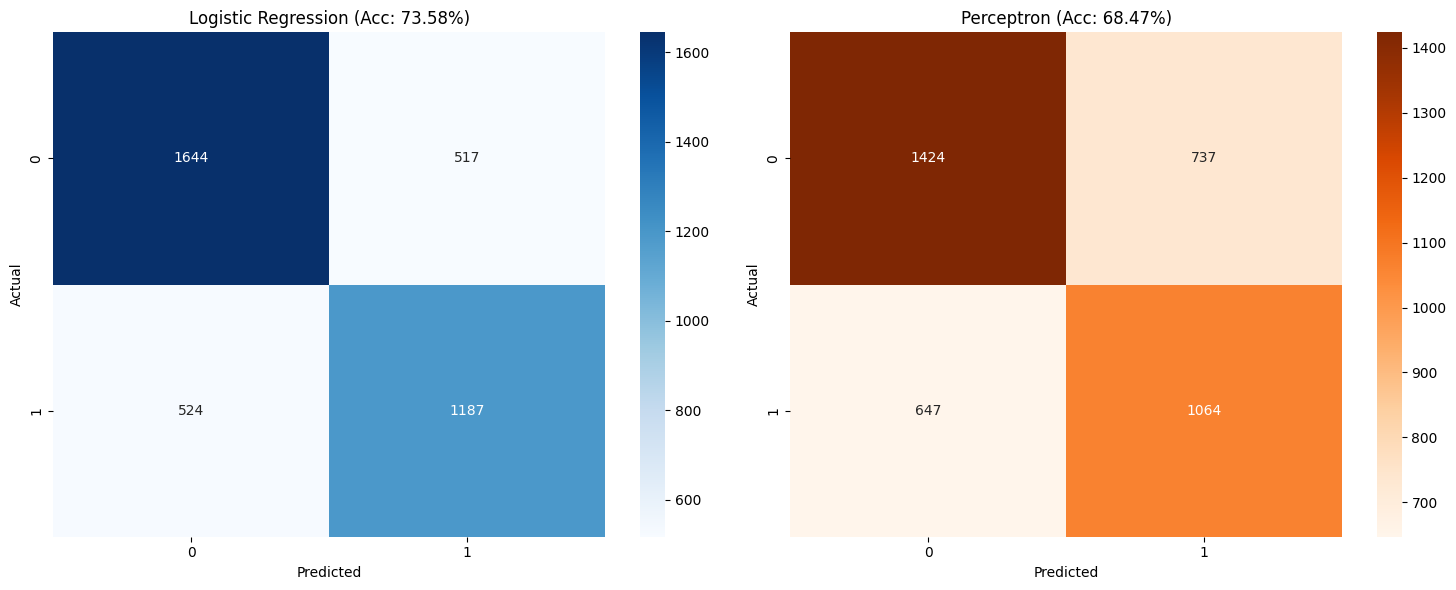

In [7]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LogReg CM
cm_log = confusion_matrix(y_test, gs_log.best_estimator_.predict(X_test_final))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f"Logistic Regression (Acc: {gs_log.best_score_:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Perceptron CM
cm_perc = confusion_matrix(y_test, gs_perc.best_estimator_.predict(X_test_final))
sns.heatmap(cm_perc, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f"Perceptron (Acc: {gs_perc.best_score_:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Step 8: Comparative Decision Boundaries
Using 2D PCA to show the 'Line in the Sand' for both linear classifiers.

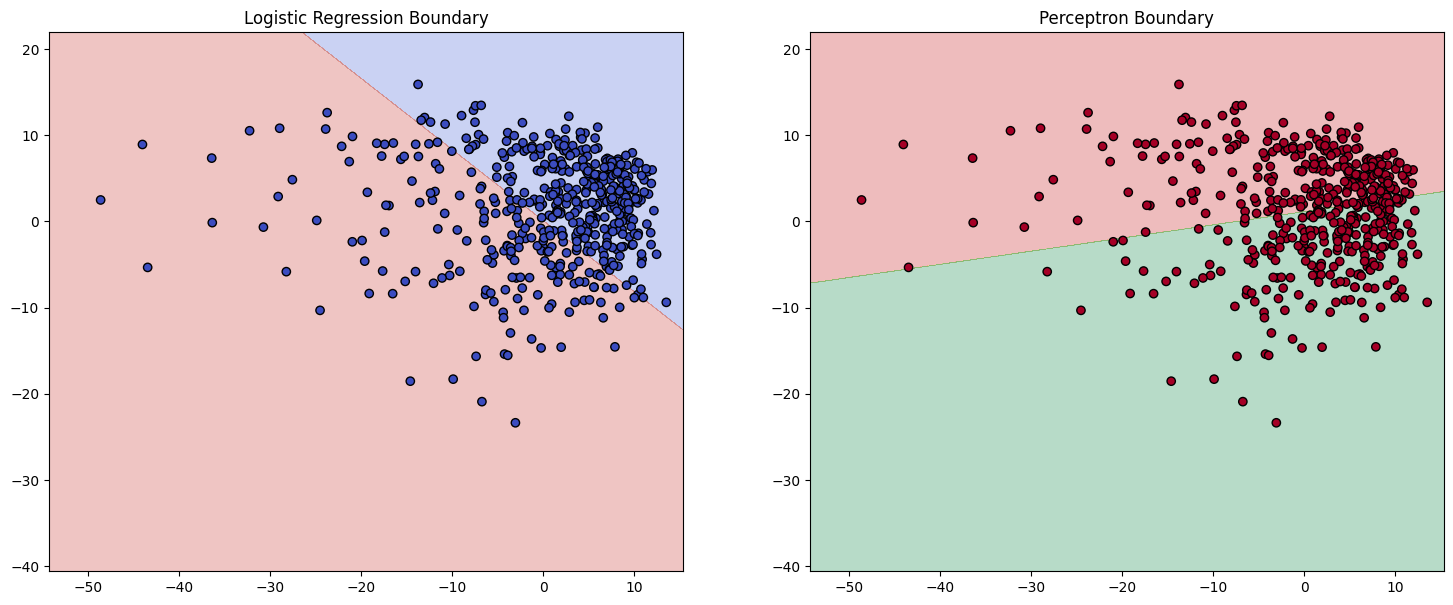

In [8]:
from sklearn.decomposition import PCA

# 1. Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_final)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
h = .02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 2. Visualize LogReg
vis_log = LogisticRegression(**gs_log.best_params_).fit(X_pca, y_train_bal)
Z1 = vis_log.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax1.contourf(xx, yy, Z1, alpha=0.3, cmap=plt.cm.coolwarm)
ax1.scatter(X_pca[:500, 0], X_pca[:500, 1], c=y_train_bal[:500], edgecolors='k', cmap=plt.cm.coolwarm)
ax1.set_title("Logistic Regression Boundary")

# 3. Visualize Perceptron
vis_perc = Perceptron(**gs_perc.best_params_).fit(X_pca, y_train_bal)
Z2 = vis_perc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx, yy, Z2, alpha=0.3, cmap=plt.cm.RdYlGn)
ax2.scatter(X_pca[:500, 0], X_pca[:500, 1], c=y_train_bal[:500], edgecolors='k', cmap=plt.cm.RdYlGn)
ax2.set_title("Perceptron Boundary")

plt.show()

## Step 9: Save Best Models
Persist the best estimators for future comparison and deployment.

In [9]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(gs_log.best_estimator_, "models/logistic_regression_best.pkl")
joblib.dump(gs_perc.best_estimator_, "models/perceptron_best.pkl")
print("[System] Best linear models saved to \"models/\" directory.")

[System] Best linear models saved to "models/" directory.
